#### Question 1

In [8]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
K = 5

grid = np.arange(1, K + 1) / K
print(grid)

[0.2 0.4 0.6 0.8 1. ]


In [10]:
n = 5_000

draws = np.random.choice(grid, size=n)
print(draws[:10])

[0.4 1.  0.6 0.4 0.6 0.2 0.6 1.  0.2 1. ]


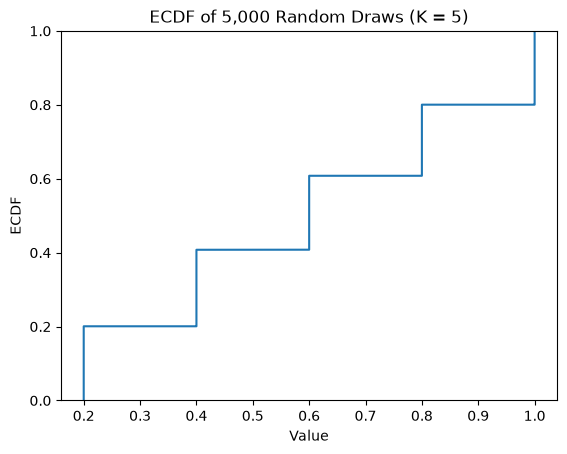

In [11]:
sns.ecdfplot(x=draws)

plt.xlabel("Value")
plt.ylabel("ECDF")
plt.title("ECDF of 5,000 Random Draws (K = 5)")
plt.show()

As we increase K, we increase the number of possible values between 0 and 1. This makes jumps in the ECDF smaller, so the graph starts looking almost like a straight line, approaching uniform distribution

#### Question 2

In [12]:

n = 32

data = np.random.uniform(-np.sqrt(3), np.sqrt(3), size=n)
print(data)

[-8.51572719e-01  1.15717583e+00  1.48079851e+00  1.05913578e+00
 -8.33613062e-01  3.49406938e-01  3.45399131e-01 -7.85815920e-02
  3.89072739e-01  3.20333066e-01  1.47013860e+00 -1.33320100e+00
  6.89950241e-01  2.45204031e-01 -1.44642082e+00  1.41487373e+00
 -1.67013686e+00  2.28046317e-01  6.72369918e-01 -6.77403875e-02
 -5.34959652e-01  1.31646479e-02 -5.56363421e-01 -5.44613860e-01
 -6.79828334e-04  2.09912086e-01  1.57969924e+00  1.69699408e-01
  1.29724434e+00 -8.00668442e-02  5.95974655e-01 -1.35412371e+00]


In [13]:
sample_mean = np.mean(data)
result = sample_mean * np.sqrt(n)

print("Sample mean:", sample_mean)
print("Result:", result)

Sample mean: 0.13548517043333042
Result: 0.7664198621089846


In [ ]:
b = 5_000

results = []

for i in range(b):
    data = np.random.uniform(-np.sqrt(3), np.sqrt(3), size=n)
    sample_mean = np.mean(data)
    result = sample_mean * np.sqrt(n)
    results.append(result)

print(results[:10])

[np.float64(0.6815117372109321), np.float64(-1.7684581281636915), np.float64(-0.8685781308565403), np.float64(0.25420538283257194), np.float64(-0.22806980046815692), np.float64(-1.554815666022338), np.float64(-1.1134298140928938), np.float64(-1.5243298438301547), np.float64(-0.8254673356055523), np.float64(1.446788336241626)]


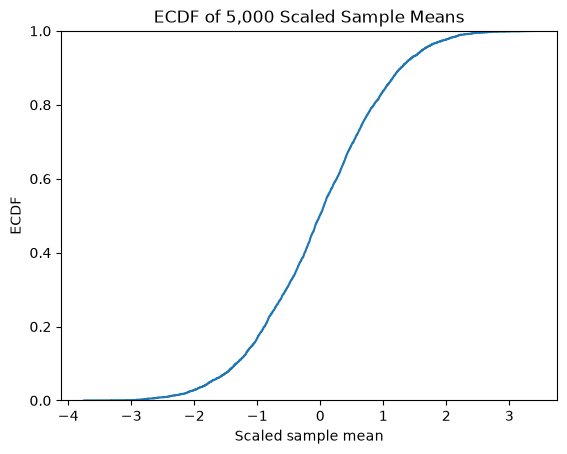

In [15]:
sns.ecdfplot(x=results)

plt.xlabel("Scaled sample mean")
plt.ylabel("ECDF")
plt.title("ECDF of 5,000 Scaled Sample Means")
plt.show()

As n increases, the ECDF approaches an s shaped curve because the sample means tend to be close to 0, approaching standard normal distribution.

#### Question 3

In [ ]:
n = 40
p = 0.5

coins = np.random.choice([0, 1], size=n, p=[1-p, p])
print(coins)
print("Number of heads:", np.sum(coins))

[0 0 1 1 1 0 0 0 0 1 0 1 1 1 0 1 1 1 1 0 1 0 0 1 0 1 1 1 1 0 1 0 1 1 1 1 0
 1 0 1]
Number of heads: 24


In [17]:
heads = np.sum(coins)
expected_heads = n * p
standard_deviation = np.sqrt(n * p * (1-p))
result = (heads - expected_heads) / standard_deviation

print("Heads:", heads)
print("Expected heads:", expected_heads)
print("Standard deviation:", standard_deviation)
print("Result:", result)

Heads: 24
Expected heads: 20.0
Standard deviation: 3.1622776601683795
Result: 1.2649110640673518


In [18]:
b = 5_000

results = []

for i in range(b):
    coins = np.random.choice([0, 1], size=n, p=[1-p, p])
    heads = np.sum(coins)

    result = (heads - expected_heads) / standard_deviation

    results.append(result)

print(results[:10])

[np.float64(0.9486832980505138), np.float64(0.31622776601683794), np.float64(0.0), np.float64(-1.5811388300841895), np.float64(-0.9486832980505138), np.float64(-0.31622776601683794), np.float64(0.0), np.float64(-0.6324555320336759), np.float64(-0.6324555320336759), np.float64(1.2649110640673518)]


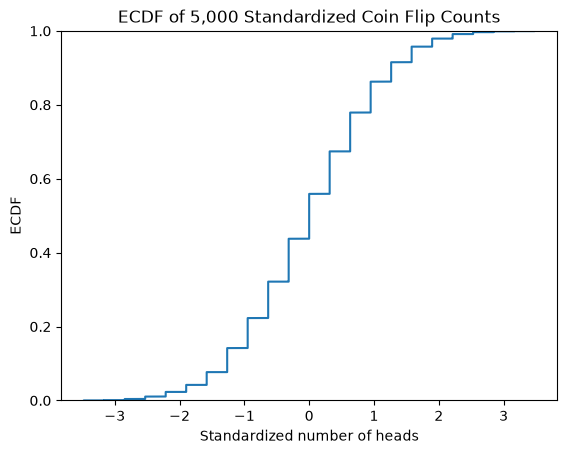

In [19]:
sns.ecdfplot(x=results)

plt.xlabel("Standardized number of heads")
plt.ylabel("ECDF")
plt.title("ECDF of 5,000 Standardized Coin Flip Counts")
plt.show()

As n increases, the ECDF approaches an s shaped curve. because the standardized counts tend to be close to 0. also the steps become smaller, and the distribution approaches a standard normal distribution.

#### Question 4

In [20]:
import numpy as np

r = 1
dt = 1e-3

period = 0
terminated = False

while not terminated:
    period += 1
    terminated = np.random.random() < r * dt

print("Termination period:", period)

Termination period: 361


In [21]:
termination_time = period * dt

print("Termination time:", termination_time)

Termination time: 0.361


In [22]:
n = 5_000

termination_times = []

for i in range(n):
    period = 0
    terminated = False

    while not terminated:
        period += 1
        terminated = np.random.random() < r * dt

    termination_time = period * dt
    termination_times.append(termination_time)

print(termination_times[:10])

[0.837, 0.225, 0.658, 0.514, 0.234, 1.029, 0.059000000000000004, 0.748, 3.936, 0.672]


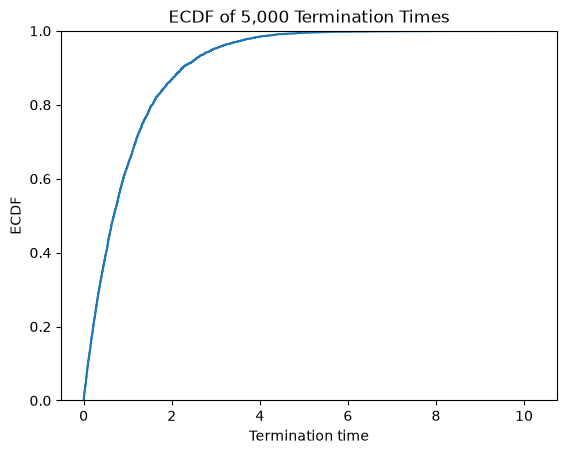

In [23]:
sns.ecdfplot(x=termination_times)

plt.xlabel("Termination time")
plt.ylabel("ECDF")
plt.title("ECDF of 5,000 Termination Times")
plt.show()

As r increases, processes tend to terminate sooner, so the line rises faster and approaches a flat line, approaching an exponential distribution.

#### Question 5

In [24]:
K = 20

values = np.random.uniform(0, 1, size=K)
print(values)

[0.09292966 0.369418   0.5596602  0.35658723 0.11982952 0.86404401
 0.37231572 0.34818179 0.2532594  0.9669858  0.06378675 0.24189501
 0.9370151  0.74547082 0.9528818  0.83067559 0.30906964 0.07911347
 0.48605152 0.81076542]


In [25]:
sorted_values = np.sort(values)
largest_value = sorted_values[-1]

print("Sorted values:", sorted_values)
print("Largest value:", largest_value)

Sorted values: [0.06378675 0.07911347 0.09292966 0.11982952 0.24189501 0.2532594
 0.30906964 0.34818179 0.35658723 0.369418   0.37231572 0.48605152
 0.5596602  0.74547082 0.81076542 0.83067559 0.86404401 0.9370151
 0.9528818  0.9669858 ]
Largest value: 0.9669858010569101


In [26]:
n = 5_000

largest_values = []

for i in range(n):
    values = np.random.uniform(0, 1, size=K)
    sorted_values = np.sort(values)
    largest_value = sorted_values[-1]

    largest_values.append(largest_value)

print(largest_values[:10])

[np.float64(0.913648597900608), np.float64(0.852296550070378), np.float64(0.9570915739244088), np.float64(0.9699248170917409), np.float64(0.9502197818694867), np.float64(0.9793242589748978), np.float64(0.987865036848974), np.float64(0.722033360879359), np.float64(0.995214937293653), np.float64(0.9255154786398133)]


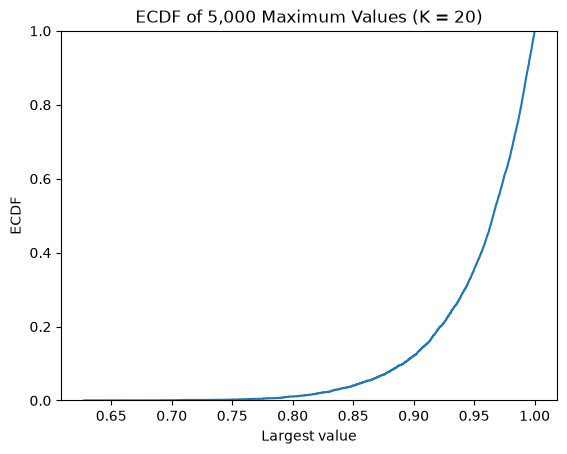

In [27]:
sns.ecdfplot(x=largest_values)

plt.xlabel("Largest value")
plt.ylabel("ECDF")
plt.title("ECDF of 5,000 Maximum Values (K = 20)")
plt.show()

As we repeat the experiment, we see that most maximum values are close to 1, approaching the CDF of a Beta(20, 1) distribution

#### Question 6

In [28]:
delta = 1 / 100

state = 1

steps = int(1 / delta)

print("Starting state:", state)
print("Number of steps:", steps)

Starting state: 1
Number of steps: 100


In [29]:
u = np.exp(np.sqrt(delta))
d = np.exp(-np.sqrt(delta))

p = 0.5

print("Upward factor:", u)
print("Downward factor:", d)

Upward factor: 1.1051709180756477
Downward factor: 0.9048374180359595


In [30]:
state = 1

for i in range(steps):
    move = np.random.choice([u, d], p=[p, 1-p])
    state = state * move

print("Final state:", state)

Final state: 1.22140275816017


In [31]:
B = 1_000

final_positions = []

for i in range(B):
    state = 1

    for j in range(steps):
        move = np.random.choice([u, d], p=[p, 1-p])
        state = state * move

    final_positions.append(state)

print(final_positions[:10])

[np.float64(0.8187307530779819), np.float64(1.0), np.float64(0.16529888822158634), np.float64(1.2214027581601703), np.float64(0.5488116360940263), np.float64(0.6703200460356392), np.float64(0.8187307530779819), np.float64(1.8221188003905102), np.float64(4.055199966844679), np.float64(0.2018965179946552)]


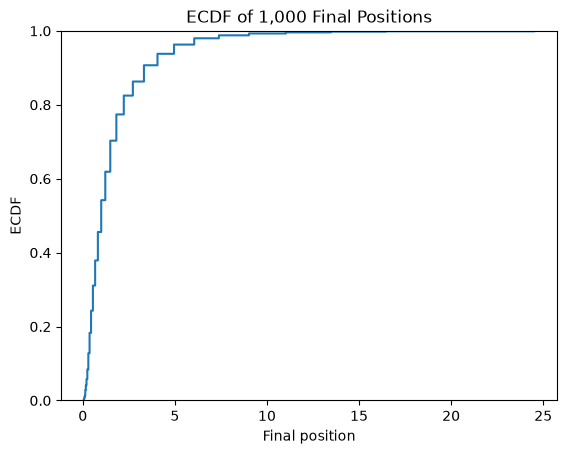

In [32]:
sns.ecdfplot(x=final_positions)

plt.xlabel("Final position")
plt.ylabel("ECDF")
plt.title("ECDF of 1,000 Final Positions")
plt.show()

As delta gets smaller, we approach a lognormal distribution. Value keeps going up or down by small percentages, most final positions are relatively small, while a few become much larger.


#### Question 7

In [34]:
K = 100_000

ranks = np.arange(1, K + 1)
print(ranks[:10])
print(ranks[-10:])

[ 1  2  3  4  5  6  7  8  9 10]
[ 99991  99992  99993  99994  99995  99996  99997  99998  99999 100000]


In [35]:
s = 1
sizes = (K / ranks) ** s

print(sizes[:10])
print(sizes[-10:])

[100000.          50000.          33333.33333333  25000.
  20000.          16666.66666667  14285.71428571  12500.
  11111.11111111  10000.        ]
[1.00009001 1.00008001 1.00007    1.00006    1.00005    1.00004
 1.00003    1.00002    1.00001    1.        ]


In [36]:
n = 5_000

sampled_ranks = np.random.choice(ranks, size=n)
sampled_sizes = (K / sampled_ranks) ** s

print("Sampled ranks:", sampled_ranks[:10])
print("Corresponding sizes:", sampled_sizes[:10])

Sampled ranks: [70720 87938 90139 51275 20549  6945  7983  9703 80310 26056]
Corresponding sizes: [ 1.41402715  1.13716482  1.10939771  1.95026816  4.86641686 14.39884809
 12.52661907 10.3060909   1.24517495  3.83788763]


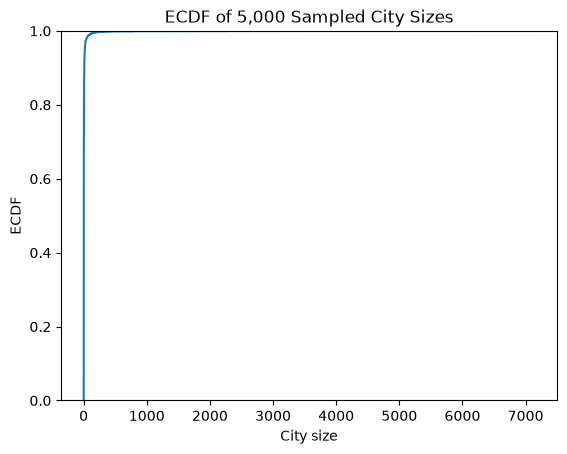

In [37]:
sns.ecdfplot(x=sampled_sizes)

plt.xlabel("City size")
plt.ylabel("ECDF")
plt.title("ECDF of 5,000 Sampled City Sizes")
plt.show()

As K increases, the city sizes approach a Pareto distribution. Most cities have relatively small sizes, while a few are extremely large.

In [38]:
s = 2
sampled_sizes = (K / sampled_ranks) ** s

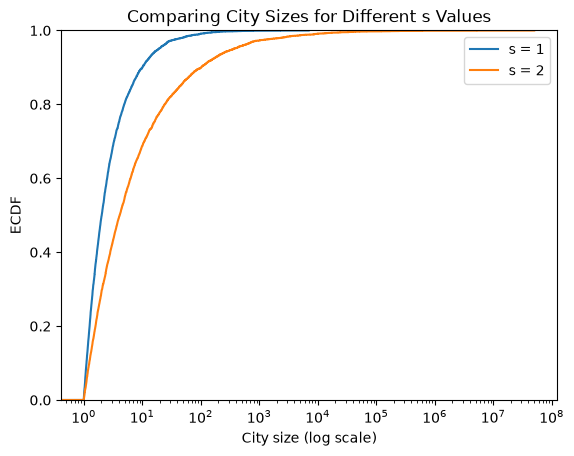

In [40]:
sns.ecdfplot(x=sizes_s1, label="s = 1")
sns.ecdfplot(x=sizes_s2, label="s = 2")

plt.xscale("log")

plt.xlabel("City size (log scale)")
plt.ylabel("ECDF")
plt.title("Comparing City Sizes for Different s Values")
plt.legend()
plt.show()

As s increases, the larger cities become much bigger compared with the smaller ones, creating a longer right tail.

#### Question 8

In [41]:
n = 1_000

energies = np.ones(n)

print(energies[:10])
print("Total energy:", np.sum(energies))

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Total energy: 1000.0


In [42]:
i, j = np.random.choice(n, size=2, replace=False)

E = energies[i] + energies[j]

u = np.random.uniform(0, 1)

energies[i] = u * E
energies[j] = (1 - u) * E

print("Particle i:", i, "New energy:", energies[i])
print("Particle j:", j, "New energy:", energies[j])
print("Total energy:", np.sum(energies))

Particle i: 913 New energy: 0.7393105673157268
Particle j: 230 New energy: 1.2606894326842732
Total energy: 1000.0


In [43]:
energies = np.ones(n)

b = 1_000_000

for k in range(b):
    i, j = np.random.choice(n, size=2, replace=False)

    E = energies[i] + energies[j]
    u = np.random.uniform(0, 1)

    energies[i] = u * E
    energies[j] = (1 - u) * E

print("First 10 final energies:", energies[:10])
print("Total energy:", np.sum(energies))

First 10 final energies: [0.18739725 1.16496464 0.97761623 0.27633334 2.71934112 0.06119965
 5.2645495  0.85541418 0.43209651 1.57513124]
Total energy: 1000.0


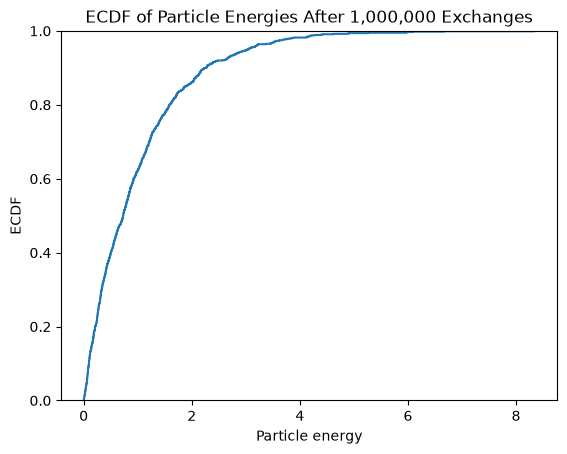

In [44]:
sns.ecdfplot(x=energies)

plt.xlabel("Particle energy")
plt.ylabel("ECDF")
plt.title("ECDF of Particle Energies After 1,000,000 Exchanges")
plt.show()